# Blunder prediction from Lichess engine-eval data

This notebook builds a first supervised ML task for the final project:

> Given the current state of a game, predict whether the player to move will
> make a blunder within their next few moves.

The notebook is written to be dropped into:

```text
scratch/blunder_prediction_01.ipynb
```

It expects the processed data to live at:

```text
data/processed/lichess-2017-05-eval-all/
```

The goal is not to make the perfect model immediately. The goal is to get a
clean baseline pipeline working end-to-end:

1. Load processed game/ply/features data.
2. Define a blunder target from engine-evaluation drops.
3. Build legal, pre-blunder features.
4. Train simple baseline models.
5. Evaluate performance without relying only on accuracy.
6. Inspect which features matter.


## 0. Notebook conventions

This notebook follows the formatting style used in the project:

- 2-space indents.
- Code lines kept short where practical.
- Exploratory, block-by-block workflow.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
  ConfusionMatrixDisplay,
  PrecisionRecallDisplay,
  RocCurveDisplay,
  average_precision_score,
  balanced_accuracy_score,
  classification_report,
  confusion_matrix,
  f1_score,
  roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
pd.set_option("display.max_columns", 120)


## 1. Locate the project root and load the data

This block should work whether you launch Jupyter from the project root or from
`scratch/`.


In [2]:
def find_project_root(start=None):
  if start is None:
    start = Path.cwd()

  start = Path(start).resolve()

  for path in [start, *start.parents]:
    has_pyproject = (path / "pyproject.toml").exists()
    has_data = (path / "data").exists()

    if has_pyproject and has_data:
      return path

  raise FileNotFoundError(
    "Could not find project root. Run from the project root "
    "or from a subdirectory such as scratch/."
  )


ROOT = find_project_root()
DATA_DIR = ROOT / "data" / "processed" / "lichess-2017-05-eval-all"

GAMES_PATH = DATA_DIR / "games.parquet"
PLIES_PATH = DATA_DIR / "plies.parquet"
FEATURES_PATH = DATA_DIR / "features.parquet"
DICT_PATH = DATA_DIR / "feature_dictionary.csv"

print(f"Project root: {ROOT}")
print(f"Data dir:     {DATA_DIR}")

for path in [GAMES_PATH, PLIES_PATH, FEATURES_PATH, DICT_PATH]:
  print(f"{path.name:24s} exists={path.exists()}")


Project root: /Users/asudler/Desktop/ucph/coursework/2526-block4/aml/final-project/root/workspace/aidan_sandbox/blunder
Data dir:     /Users/asudler/Desktop/ucph/coursework/2526-block4/aml/final-project/root/workspace/aidan_sandbox/blunder/data/processed/lichess-2017-05-eval-all
games.parquet            exists=True
plies.parquet            exists=True
features.parquet         exists=True
feature_dictionary.csv   exists=True


In [3]:
games = pd.read_parquet(GAMES_PATH)
plies = pd.read_parquet(PLIES_PATH)
features = pd.read_parquet(FEATURES_PATH)

if DICT_PATH.exists():
  feature_dict = pd.read_csv(DICT_PATH)
else:
  feature_dict = pd.DataFrame()

print("games:", games.shape)
print("plies:", plies.shape)
print("features:", features.shape)
print("feature_dict:", feature_dict.shape)


games: (957369, 17)
plies: (61361243, 39)
features: (957369, 80)
feature_dict: (6, 5)


## 2. Quick schema inspection

Run these cells first and check whether the detected columns look sensible.

The rest of the notebook uses helper functions to infer likely column names, but
you should still inspect the output. If the auto-detection guesses wrong, edit the
small `COLUMN_OVERRIDES` dictionary below.


In [4]:
print("games columns")
display(pd.DataFrame({"column": games.columns}))

print("plies columns")
display(pd.DataFrame({"column": plies.columns}))

print("features columns")
display(pd.DataFrame({"column": features.columns}))


games columns


,column
0,game_index
1,event
2,site
3,white
4,black
5,result
6,result_white
7,white_elo
8,black_elo
9,avg_elo


plies columns


,column
0,game_index
1,ply
2,move_number
3,side
4,san_raw
5,comment_raw
6,eval_raw
7,eval_pawns
8,is_mate_eval
9,mate_distance


features columns


,column
0,game_index
1,n_plies
2,n_eval_available
3,frac_eval_available
4,n_missing_eval
...,...
75,opening
76,time_control
77,time_base_seconds
78,time_increment_seconds


In [5]:
if len(feature_dict) > 0:
  display(feature_dict.head(50))


,table,column,meaning,raw_or_derived,unit
0,plies,eval_pawns,Engine eval from White's perspective in pawn u...,raw-parsed,pawns
1,plies,eval_proxy,Finite mate-aware numeric eval used for summar...,derived,pawns proxy
2,plies,phase_progress,Fraction of starting non-pawn material removed.,derived,unitless
3,features,mean_abs_eval_change,Mean absolute change in eval_proxy per ply.,derived,pawns proxy
4,features,white_mean_loss_proxy,Mean eval loss after White moves.,derived,pawns proxy
5,features,black_mean_loss_proxy,Mean eval loss after Black moves.,derived,pawns proxy


In [7]:
COLUMN_OVERRIDES = {
  # Fill these in only if auto-detection below guesses wrong.
  #
  # Examples:
  # "game_id": "game_id",
  # "ply_index": "ply_index",
  # "eval_cp": "eval_cp",
  # "turn": "turn",
}


In [8]:
def pick_column(df, candidates, required=True, role="column"):
  for name in candidates:
    if name in COLUMN_OVERRIDES:
      override = COLUMN_OVERRIDES[name]
      if override in df.columns:
        return override

  for name in candidates:
    if name in df.columns:
      return name

  if required:
    cols = ", ".join(candidates)
    raise KeyError(f"Could not find {role}. Tried: {cols}")

  return None


def pick_contains(df, include, exclude=None, required=True, role="column"):
  if exclude is None:
    exclude = []

  include = [x.lower() for x in include]
  exclude = [x.lower() for x in exclude]

  matches = []
  for col in df.columns:
    low = col.lower()
    has_all = all(x in low for x in include)
    has_excl = any(x in low for x in exclude)
    if has_all and not has_excl:
      matches.append(col)

  if matches:
    return matches[0]

  if required:
    raise KeyError(f"Could not find {role} containing {include}")

  return None


game_id_col = pick_column(
  plies,
  ["game_id", "game_index", "game_idx", "id"],
  role="game id column",
)

ply_col = pick_column(
  plies,
  ["ply", "ply_index", "ply_number", "move_ply"],
  role="ply index column",
)

eval_col = pick_column(
  plies,
  [
    "eval_cp",
    "cp",
    "centipawn",
    "stockfish_eval_cp",
    "engine_eval_cp",
  ],
  required=False,
  role="engine eval cp column",
)

if eval_col is None:
  eval_col = pick_contains(
    plies,
    ["eval"],
    exclude=["mate", "raw", "comment"],
    role="engine eval cp column",
  )

turn_col = pick_column(
  plies,
  ["turn", "side", "color", "player_color"],
  required=False,
  role="side-to-move column",
)

print("Detected columns")
print("game_id_col:", game_id_col)
print("ply_col:    ", ply_col)
print("eval_col:   ", eval_col)
print("turn_col:   ", turn_col)


Detected columns
game_id_col: game_index
ply_col:     ply
eval_col:    eval_pawns
turn_col:    side


## 3. Define blunders from engine-evaluation drops

We define blunders from the change in engine evaluation from one ply to the next.

Important convention:

- Engine eval is assumed to be from **White's perspective**.
- Positive eval means White is better.
- Negative eval means Black is better.

For the player who just moved:

- If White moved, a bad move causes `eval_after - eval_before` to decrease.
- If Black moved, a bad move causes `eval_after - eval_before` to increase.

So we convert the eval change to **loss from the mover's perspective**.


In [9]:
BLUNDER_CP = 200
MISTAKE_CP = 100
HORIZON_OWN_MOVES = 5

MAX_ABS_CP = 5000


In [10]:
def normalize_turn_value(x):
  if pd.isna(x):
    return np.nan

  value = str(x).strip().lower()

  if value in {"w", "white", "1", "true"}:
    return "white"

  if value in {"b", "black", "0", "false"}:
    return "black"

  return value


def add_basic_ply_columns(df):
  df = df.copy()
  df = df.sort_values([game_id_col, ply_col]).reset_index(drop=True)

  df["eval_cp"] = pd.to_numeric(df[eval_col], errors="coerce")
  df["eval_cp"] = df["eval_cp"].clip(-MAX_ABS_CP, MAX_ABS_CP)

  if turn_col is not None:
    df["side_to_move"] = df[turn_col].map(normalize_turn_value)
  else:
    df["side_to_move"] = np.where(df[ply_col] % 2 == 1, "white", "black")

  df["mover"] = df["side_to_move"]
  df["ply_number"] = pd.to_numeric(df[ply_col], errors="coerce")
  df["fullmove_number"] = ((df["ply_number"] + 1) // 2).astype("Int64")

  return df


plies_ml = add_basic_ply_columns(plies)

display(plies_ml[
  [game_id_col, ply_col, "side_to_move", "eval_cp"]
].head(20))


,game_index,ply,side_to_move,eval_cp
0,85,1,white,0.03
1,85,2,black,-0.01
2,85,3,white,-0.09
3,85,4,black,0.19
4,85,5,white,0.11
5,85,6,black,0.13
6,85,7,white,-0.13
7,85,8,black,0.37
8,85,9,white,0.06
9,85,10,black,0.05


In [11]:
def add_blunder_labels(df):
  df = df.copy()
  group = df.groupby(game_id_col, sort=False)

  df["eval_after_cp"] = group["eval_cp"].shift(-1)
  df["eval_delta_cp"] = df["eval_after_cp"] - df["eval_cp"]

  white_loss = -df["eval_delta_cp"]
  black_loss = df["eval_delta_cp"]

  df["cp_loss"] = np.where(
    df["mover"].eq("white"),
    white_loss,
    black_loss,
  )

  df["cp_loss"] = df["cp_loss"].clip(lower=0)
  df["is_mistake"] = df["cp_loss"].ge(MISTAKE_CP).astype(int)
  df["is_blunder"] = df["cp_loss"].ge(BLUNDER_CP).astype(int)

  return df


plies_ml = add_blunder_labels(plies_ml)

cols = [
  game_id_col,
  ply_col,
  "mover",
  "eval_cp",
  "eval_after_cp",
  "eval_delta_cp",
  "cp_loss",
  "is_blunder",
]

display(plies_ml[cols].head(20))


,game_index,ply,mover,eval_cp,eval_after_cp,eval_delta_cp,cp_loss,is_blunder
0,85,1,white,0.03,-0.01,-0.04,0.04,0
1,85,2,black,-0.01,-0.09,-0.08,0.00,0
2,85,3,white,-0.09,0.19,0.28,0.00,0
3,85,4,black,0.19,0.11,-0.08,0.00,0
4,85,5,white,0.11,0.13,0.02,0.00,0
5,85,6,black,0.13,-0.13,-0.26,0.00,0
6,85,7,white,-0.13,0.37,0.50,0.00,0
7,85,8,black,0.37,0.06,-0.31,0.00,0
8,85,9,white,0.06,0.05,-0.01,0.01,0
9,85,10,black,0.05,-0.02,-0.07,0.00,0


In [12]:
label_summary = plies_ml[["is_mistake", "is_blunder"]].mean()
display(label_summary.to_frame("fraction"))

plies_ml["cp_loss"].describe(percentiles=[
  0.5,
  0.75,
  0.9,
  0.95,
  0.99,
])


,fraction
is_mistake,0.000002
is_blunder,0.000000


count    5.489208e+07
mean     3.223555e-02
std      8.221098e-01
min     -0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
90%      3.000000e-02
95%      8.000000e-02
99%      2.600000e-01
max      1.238900e+02
Name: cp_loss, dtype: float64

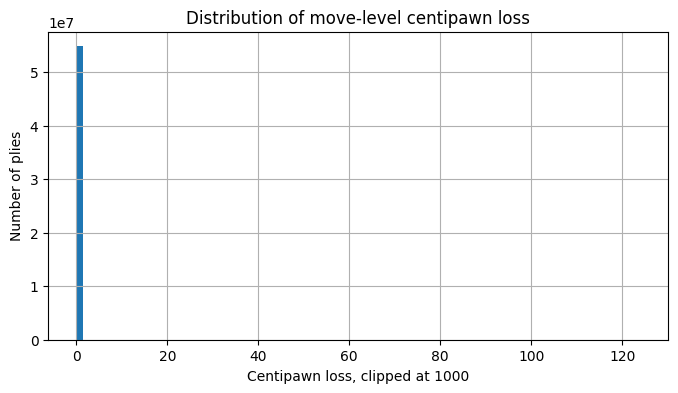

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
plies_ml["cp_loss"].clip(0, 1000).hist(bins=80, ax=ax)
ax.set_xlabel("Centipawn loss, clipped at 1000")
ax.set_ylabel("Number of plies")
ax.set_title("Distribution of move-level centipawn loss")
plt.show()


## 4. Build the forward-looking target

The model should predict whether the **current player to move** will blunder
within their next `HORIZON_OWN_MOVES` moves.

For each row, we look forward only at future moves by the same player in the
same game. The current row itself is excluded from the target.


In [14]:
def add_future_blunder_target(df, horizon_own_moves):
  parts = []

  for _, game in df.groupby(game_id_col, sort=False):
    game = game.sort_values(ply_col).copy()

    for color in ["white", "black"]:
      mask = game["mover"].eq(color)
      idx = game.index[mask]
      future = game.loc[idx, "is_blunder"]

      future_sum = pd.Series(0, index=idx, dtype=float)

      for step in range(1, horizon_own_moves + 1):
        future_sum = future_sum.add(
          future.shift(-step).fillna(0),
          fill_value=0,
        )

      game.loc[idx, "future_blunder_count"] = future_sum

    parts.append(game)

  out = pd.concat(parts, axis=0).sort_index()
  out["will_blunder_soon"] = out["future_blunder_count"].gt(0).astype(int)

  return out


plies_ml = add_future_blunder_target(plies_ml, HORIZON_OWN_MOVES)

target_rate = plies_ml["will_blunder_soon"].mean()
print(f"Target rate: {target_rate:.4f}")

display(plies_ml[
  [
    game_id_col,
    ply_col,
    "mover",
    "is_blunder",
    "future_blunder_count",
    "will_blunder_soon",
  ]
].head(30))


KeyboardInterrupt: 

## 5. Create pre-blunder features

These features are allowed because they use only information available up to the
current position.

We intentionally avoid these leakage features:

- `eval_after_cp`
- `eval_delta_cp`
- `cp_loss`
- `is_mistake`
- `is_blunder`
- future-looking labels


In [ ]:
def add_rolling_features(df):
  df = df.copy()
  df = df.sort_values([game_id_col, ply_col]).reset_index(drop=True)

  group = df.groupby(game_id_col, sort=False)

  df["abs_eval_cp"] = df["eval_cp"].abs()
  df["eval_sign"] = np.sign(df["eval_cp"]).astype(float)

  df["eval_prev_1"] = group["eval_cp"].shift(1)
  df["eval_prev_2"] = group["eval_cp"].shift(2)
  df["eval_prev_4"] = group["eval_cp"].shift(4)

  df["eval_change_prev_1"] = df["eval_cp"] - df["eval_prev_1"]
  df["eval_change_prev_2"] = df["eval_cp"] - df["eval_prev_2"]
  df["eval_change_prev_4"] = df["eval_cp"] - df["eval_prev_4"]

  df["abs_eval_change_prev_1"] = df["eval_change_prev_1"].abs()
  df["abs_eval_change_prev_2"] = df["eval_change_prev_2"].abs()
  df["abs_eval_change_prev_4"] = df["eval_change_prev_4"].abs()

  df["game_ply_fraction"] = group.cumcount()
  max_ply = group["game_ply_fraction"].transform("max").replace(0, np.nan)
  df["game_ply_fraction"] = df["game_ply_fraction"] / max_ply

  df["phase"] = pd.cut(
    df["fullmove_number"].astype(float),
    bins=[0, 10, 25, 10_000],
    labels=["opening", "middlegame", "endgame"],
    include_lowest=True,
  )

  return df


plies_ml = add_rolling_features(plies_ml)


In [ ]:
def add_player_history_features(df):
  df = df.copy()
  df = df.sort_values([game_id_col, ply_col]).reset_index(drop=True)

  keys = [game_id_col, "mover"]
  group = df.groupby(keys, sort=False)

  prev_blunder = group["is_blunder"].shift(1).fillna(0)
  prev_mistake = group["is_mistake"].shift(1).fillna(0)
  prev_cp_loss = group["cp_loss"].shift(1)

  df["prev_own_blunders"] = prev_blunder.groupby(
    [df[game_id_col], df["mover"]],
    sort=False,
  ).cumsum()

  df["prev_own_mistakes"] = prev_mistake.groupby(
    [df[game_id_col], df["mover"]],
    sort=False,
  ).cumsum()

  df["prev_own_cp_loss"] = prev_cp_loss

  for window in [3, 5, 10]:
    shifted_loss = group["cp_loss"].shift(1)

    rolled = shifted_loss.groupby(
      [df[game_id_col], df["mover"]],
      sort=False,
    ).rolling(window, min_periods=1).mean()

    df[f"prev_own_cp_loss_mean_{window}"] = (
      rolled.reset_index(level=[0, 1], drop=True)
    )

  return df


plies_ml = add_player_history_features(plies_ml)


In [ ]:
candidate_features = [
  "eval_cp",
  "abs_eval_cp",
  "eval_sign",
  "fullmove_number",
  "game_ply_fraction",
  "eval_prev_1",
  "eval_prev_2",
  "eval_prev_4",
  "eval_change_prev_1",
  "eval_change_prev_2",
  "eval_change_prev_4",
  "abs_eval_change_prev_1",
  "abs_eval_change_prev_2",
  "abs_eval_change_prev_4",
  "prev_own_blunders",
  "prev_own_mistakes",
  "prev_own_cp_loss",
  "prev_own_cp_loss_mean_3",
  "prev_own_cp_loss_mean_5",
  "prev_own_cp_loss_mean_10",
  "mover",
  "phase",
]

feature_cols = [c for c in candidate_features if c in plies_ml.columns]

leakage_cols = [
  "eval_after_cp",
  "eval_delta_cp",
  "cp_loss",
  "is_mistake",
  "is_blunder",
  "future_blunder_count",
  "will_blunder_soon",
]

print("Feature columns:")
for col in feature_cols:
  print(" ", col)

print()
print("Leakage columns intentionally excluded:")
for col in leakage_cols:
  print(" ", col)


In [ ]:
model_df = plies_ml.dropna(subset=["will_blunder_soon"]).copy()

# Last few plies have no future horizon. Keep the label as "no future
# blunder" for now, but this can bias the task. This optional filter removes
# the last 2 * horizon plies of each game.
group = model_df.groupby(game_id_col, sort=False)
max_ply = group[ply_col].transform("max")
min_future_gap = 2 * HORIZON_OWN_MOVES
model_df = model_df[model_df[ply_col] <= max_ply - min_future_gap].copy()

X = model_df[feature_cols]
y = model_df["will_blunder_soon"].astype(int)
groups = model_df[game_id_col]

print("Model rows:", len(model_df))
print("Positive rate:", y.mean())
display(X.head())


## 6. Train/validation/test split by game

We split by `game_id`, not by row. This matters because plies from the same game
are highly correlated.

The split is:

- 70% train
- 15% validation
- 15% test

Use the validation set for model choices. Use the test set only at the end.


In [ ]:
def group_train_valid_test_split(X, y, groups, seed=RANDOM_STATE):
  splitter_1 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=seed,
  )

  train_idx, temp_idx = next(splitter_1.split(X, y, groups))

  X_train = X.iloc[train_idx]
  y_train = y.iloc[train_idx]
  g_train = groups.iloc[train_idx]

  X_temp = X.iloc[temp_idx]
  y_temp = y.iloc[temp_idx]
  g_temp = groups.iloc[temp_idx]

  splitter_2 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.50,
    random_state=seed,
  )

  valid_rel, test_rel = next(splitter_2.split(X_temp, y_temp, g_temp))

  X_valid = X_temp.iloc[valid_rel]
  y_valid = y_temp.iloc[valid_rel]
  g_valid = g_temp.iloc[valid_rel]

  X_test = X_temp.iloc[test_rel]
  y_test = y_temp.iloc[test_rel]
  g_test = g_temp.iloc[test_rel]

  return (
    X_train,
    X_valid,
    X_test,
    y_train,
    y_valid,
    y_test,
    g_train,
    g_valid,
    g_test,
  )


split = group_train_valid_test_split(X, y, groups)

(
  X_train,
  X_valid,
  X_test,
  y_train,
  y_valid,
  y_test,
  g_train,
  g_valid,
  g_test,
) = split

print("train:", X_train.shape, y_train.mean(), g_train.nunique())
print("valid:", X_valid.shape, y_valid.mean(), g_valid.nunique())
print("test: ", X_test.shape, y_test.mean(), g_test.nunique())


## 7. Preprocessing and models

We compare:

1. Dummy baseline.
2. Logistic regression.
3. Histogram gradient boosting.

If you have `xgboost` installed, a later optional block adds XGBoost.


In [ ]:
numeric_cols = [
  c for c in feature_cols
  if pd.api.types.is_numeric_dtype(X_train[c])
]

categorical_cols = [
  c for c in feature_cols
  if c not in numeric_cols
]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

numeric_preprocess = Pipeline([
  ("imputer", SimpleImputer(strategy="median")),
  ("scaler", StandardScaler()),
])

categorical_preprocess = Pipeline([
  ("imputer", SimpleImputer(strategy="most_frequent")),
  ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess_linear = ColumnTransformer([
  ("num", numeric_preprocess, numeric_cols),
  ("cat", categorical_preprocess, categorical_cols),
])

preprocess_tree = ColumnTransformer([
  ("num", SimpleImputer(strategy="median"), numeric_cols),
  ("cat", categorical_preprocess, categorical_cols),
])


In [ ]:
models = {
  "dummy": Pipeline([
    ("preprocess", preprocess_tree),
    ("model", DummyClassifier(strategy="prior")),
  ]),
  "logreg": Pipeline([
    ("preprocess", preprocess_linear),
    ("model", LogisticRegression(
      max_iter=1000,
      class_weight="balanced",
      random_state=RANDOM_STATE,
    )),
  ]),
  "hist_gbdt": Pipeline([
    ("preprocess", preprocess_tree),
    ("model", HistGradientBoostingClassifier(
      learning_rate=0.06,
      max_leaf_nodes=31,
      l2_regularization=0.1,
      random_state=RANDOM_STATE,
    )),
  ]),
}


In [ ]:
def get_score(model, X_eval):
  if hasattr(model, "predict_proba"):
    return model.predict_proba(X_eval)[:, 1]

  if hasattr(model, "decision_function"):
    score = model.decision_function(X_eval)
    return 1 / (1 + np.exp(-score))

  return model.predict(X_eval)


def evaluate_model(name, model, X_eval, y_eval, threshold=0.5):
  score = get_score(model, X_eval)
  pred = (score >= threshold).astype(int)

  out = {
    "model": name,
    "roc_auc": roc_auc_score(y_eval, score),
    "avg_precision": average_precision_score(y_eval, score),
    "balanced_acc": balanced_accuracy_score(y_eval, pred),
    "f1": f1_score(y_eval, pred),
    "positive_rate_pred": pred.mean(),
  }

  return out


results = []

for name, model in models.items():
  print(f"Training {name}...")
  model.fit(X_train, y_train)
  row = evaluate_model(name, model, X_valid, y_valid)
  results.append(row)

results_df = pd.DataFrame(results).sort_values(
  "avg_precision",
  ascending=False,
)

display(results_df)


## 8. Choose a better classification threshold

For rare-event prediction, threshold `0.5` is often bad. Here we scan thresholds
on the validation set and choose a threshold that maximizes F1.

You can change the criterion depending on what you care about:

- High recall: catch more future blunders, with more false alarms.
- High precision: only flag very likely future blunders.
- High F1: compromise between precision and recall.


In [ ]:
best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]

print("Best validation model:", best_model_name)

valid_score = get_score(best_model, X_valid)

threshold_rows = []
for threshold in np.linspace(0.01, 0.99, 99):
  pred = (valid_score >= threshold).astype(int)
  threshold_rows.append({
    "threshold": threshold,
    "f1": f1_score(y_valid, pred),
    "balanced_acc": balanced_accuracy_score(y_valid, pred),
    "pred_positive_rate": pred.mean(),
  })

threshold_df = pd.DataFrame(threshold_rows)
best_threshold = threshold_df.sort_values("f1", ascending=False).iloc[0]

display(threshold_df.sort_values("f1", ascending=False).head(10))
print("Selected threshold:", best_threshold["threshold"])


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
ax.plot(
  threshold_df["threshold"],
  threshold_df["balanced_acc"],
  label="Balanced accuracy",
)
ax.set_xlabel("Classification threshold")
ax.set_ylabel("Validation score")
ax.set_title("Threshold scan")
ax.legend()
plt.show()


## 9. Final test-set evaluation

Only run this after you are happy with the model choice and threshold.

If the test score is much worse than the validation score, the model-selection
process probably overfit the validation set.


In [ ]:
threshold = float(best_threshold["threshold"])

test_score = get_score(best_model, X_test)
test_pred = (test_score >= threshold).astype(int)

print("Test metrics")
print("ROC AUC:", roc_auc_score(y_test, test_score))
print("Average precision:", average_precision_score(y_test, test_score))
print("Balanced accuracy:", balanced_accuracy_score(y_test, test_pred))
print("F1:", f1_score(y_test, test_pred))
print()
print(classification_report(y_test, test_pred, digits=4))


In [ ]:
cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title(f"Confusion matrix: {best_model_name}")
plt.show()


In [ ]:
RocCurveDisplay.from_predictions(y_test, test_score)
plt.title(f"ROC curve: {best_model_name}")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, test_score)
plt.title(f"Precision-recall curve: {best_model_name}")
plt.show()


## 10. Feature importance

Permutation importance is model-agnostic: shuffle one feature at a time and see
how much the model gets worse.

This is slower than built-in tree importance, but easier to interpret.


In [ ]:
small_n = min(30_000, len(X_valid))

X_imp = X_valid.sample(small_n, random_state=RANDOM_STATE)
y_imp = y_valid.loc[X_imp.index]

perm = permutation_importance(
  best_model,
  X_imp,
  y_imp,
  n_repeats=5,
  scoring="average_precision",
  random_state=RANDOM_STATE,
  n_jobs=-1,
)

importance_df = pd.DataFrame({
  "feature": feature_cols,
  "importance_mean": perm.importances_mean,
  "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

display(importance_df)


In [ ]:
plot_df = importance_df.head(20).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(plot_df["feature"], plot_df["importance_mean"])
ax.set_xlabel("Decrease in average precision after permutation")
ax.set_title("Permutation importance")
plt.show()


## 11. Optional: XGBoost

Run this only if `xgboost` is installed in your `uv` environment.

For this kind of structured data, XGBoost is often the strongest model.


In [ ]:
try:
  from xgboost import XGBClassifier

  scale_pos_weight = (y_train.eq(0).sum() / y_train.eq(1).sum())

  xgb_model = Pipeline([
    ("preprocess", preprocess_tree),
    ("model", XGBClassifier(
      n_estimators=300,
      max_depth=4,
      learning_rate=0.04,
      subsample=0.8,
      colsample_bytree=0.8,
      objective="binary:logistic",
      eval_metric="aucpr",
      scale_pos_weight=scale_pos_weight,
      random_state=RANDOM_STATE,
      n_jobs=-1,
    )),
  ])

  xgb_model.fit(X_train, y_train)

  xgb_valid = evaluate_model(
    "xgboost",
    xgb_model,
    X_valid,
    y_valid,
  )

  display(pd.DataFrame([xgb_valid]))

except ImportError:
  print("xgboost is not installed. To add it:")
  print("uv add xgboost")


## 12. Sanity checks and possible next steps

Recommended checks before trusting the result:

1. Confirm that `eval_cp` is really from White's perspective.
2. Inspect random rows where `is_blunder == 1`.
3. Re-run with `BLUNDER_CP = 300`.
4. Re-run with `HORIZON_OWN_MOVES = 3`.
5. Remove features that may be too close to the label.
6. Compare splits by game, by opening, and by time-control.
7. Add game-level features from `features.parquet`.
8. Add move metadata features if available:
   - check
   - capture
   - promotion
   - castling
   - piece moved
   - legal move count

A nice final-project story is:

> We predict short-term blunder risk from recent engine-evaluation dynamics,
> then use feature importance to identify which game states are unstable.
